# TRAVEL & TOURISM ANALYSIS

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

## Load Data

In [2]:
df=pd.read_csv(r"Data\H1(infotact).csv")
df.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Dataset Overview

In [3]:
df.shape

(40060, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40060 entries, 0 to 40059
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   40060 non-null  int64  
 1   LeadTime                     40060 non-null  int64  
 2   ArrivalDateYear              40060 non-null  int64  
 3   ArrivalDateMonth             40060 non-null  object 
 4   ArrivalDateWeekNumber        40060 non-null  int64  
 5   ArrivalDateDayOfMonth        40060 non-null  int64  
 6   StaysInWeekendNights         40060 non-null  int64  
 7   StaysInWeekNights            40060 non-null  int64  
 8   Adults                       40060 non-null  int64  
 9   Children                     40060 non-null  int64  
 10  Babies                       40060 non-null  int64  
 11  Meal                         40060 non-null  object 
 12  Country                      39596 non-null  object 
 13  MarketSegment   

## Checking Duplicates

In [5]:
df.duplicated().sum()

np.int64(6092)

## Removing Duplicates

In [6]:
df.drop_duplicates(inplace=True)

### Rechecking the dataset shape

In [7]:
df.shape

(33968, 31)

## Checking Missing values

In [8]:
df.isnull().sum()

IsCanceled                       0
LeadTime                         0
ArrivalDateYear                  0
ArrivalDateMonth                 0
ArrivalDateWeekNumber            0
ArrivalDateDayOfMonth            0
StaysInWeekendNights             0
StaysInWeekNights                0
Adults                           0
Children                         0
Babies                           0
Meal                             0
Country                        446
MarketSegment                    0
DistributionChannel              0
IsRepeatedGuest                  0
PreviousCancellations            0
PreviousBookingsNotCanceled      0
ReservedRoomType                 0
AssignedRoomType                 0
BookingChanges                   0
DepositType                      0
Agent                            0
Company                          0
DaysInWaitingList                0
CustomerType                     0
ADR                              0
RequiredCarParkingSpaces         0
TotalOfSpecialReques

## Agent and Company contains majority null data(string),so drop

In [9]:
df.drop(['Agent','Company'],axis=1,inplace=True)

In [10]:
df

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,AssignedRoomType,BookingChanges,DepositType,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,C,3,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,C,4,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,C,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,A,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40055,0,212,2017,August,35,31,2,8,2,1,...,A,1,No Deposit,0,Transient,89.75,0,0,Check-Out,2017-09-10
40056,0,169,2017,August,35,30,2,9,2,0,...,E,0,No Deposit,0,Transient-Party,202.27,0,1,Check-Out,2017-09-10
40057,0,204,2017,August,35,29,4,10,2,0,...,E,0,No Deposit,0,Transient,153.57,0,3,Check-Out,2017-09-12
40058,0,211,2017,August,35,31,4,10,2,0,...,D,0,No Deposit,0,Contract,112.80,0,1,Check-Out,2017-09-14


## Filling missing values with unknown

In [11]:
df['Country']=df['Country'].fillna('Unknown')

### Rechecking any other missing values

In [12]:
df.isnull().sum()

IsCanceled                     0
LeadTime                       0
ArrivalDateYear                0
ArrivalDateMonth               0
ArrivalDateWeekNumber          0
ArrivalDateDayOfMonth          0
StaysInWeekendNights           0
StaysInWeekNights              0
Adults                         0
Children                       0
Babies                         0
Meal                           0
Country                        0
MarketSegment                  0
DistributionChannel            0
IsRepeatedGuest                0
PreviousCancellations          0
PreviousBookingsNotCanceled    0
ReservedRoomType               0
AssignedRoomType               0
BookingChanges                 0
DepositType                    0
DaysInWaitingList              0
CustomerType                   0
ADR                            0
RequiredCarParkingSpaces       0
TotalOfSpecialRequests         0
ReservationStatus              0
ReservationStatusDate          0
dtype: int64

## Fix Data Type

In [16]:
df['ReservationStatusDate'] = pd.to_datetime(
    df['ReservationStatusDate'],
    format='%Y-%m-%d',   # enforce correct format
    errors='coerce'
)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33968 entries, 0 to 40059
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   IsCanceled                   33968 non-null  int64         
 1   LeadTime                     33968 non-null  int64         
 2   ArrivalDateYear              33968 non-null  int64         
 3   ArrivalDateMonth             33968 non-null  object        
 4   ArrivalDateWeekNumber        33968 non-null  int64         
 5   ArrivalDateDayOfMonth        33968 non-null  int64         
 6   StaysInWeekendNights         33968 non-null  int64         
 7   StaysInWeekNights            33968 non-null  int64         
 8   Adults                       33968 non-null  int64         
 9   Children                     33968 non-null  int64         
 10  Babies                       33968 non-null  int64         
 11  Meal                         33968 non-null  o

## Feature Engineering

In [ ]:
df['Total Guest']=df['Children'] + df['Adults'] + df['Babies']

In [ ]:
df['HasChildren']=(df['Children']>0).astype(int)

In [ ]:
df['HasBabies']=(df['Babies']>0).astype(int)

In [ ]:
df['Total Stay Duration']=df['StaysInWeekendNights'] + df['StaysInWeekNights']

In [ ]:
df['Revenue']=df['ADR'] * df['Total Stay Duration']

In [ ]:
df['TotalPreviousBookings']=df['PreviousCancellations'] + df['PreviousBookingsNotCanceled']

In [ ]:
df['CancellationRate']=df['PreviousCancellations'] / (df['TotalPreviousBookings'] + 1)

In [ ]:
df['BookingChangeRate']=df['BookingChanges'] / (df['LeadTime'] + 1)

## Saving cleaned & features added Dataset to a new csv file 

In [ ]:
df.to_csv(r'Data\H1_cleaned_feature_engineering.csv')

In [ ]:
df.head()

In [ ]:
df.info()

## Treating outlier

In [ ]:
def detect_outliers_iqr(df):
    outlier_indices=[]

    for col in df.select_dtypes(include=np.number).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)].index 
        outlier_indices.extend(outliers)
    return list(set(outlier_indices))


outliers = detect_outliers_iqr(df)
print("Total outliers detected:", len(outliers))

        

In [21]:
# Remove negative ADR (invalid)
df_cleaned = df[df['ADR'] >= 0]

In [22]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33967 entries, 0 to 40059
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   IsCanceled                   33967 non-null  int64         
 1   LeadTime                     33967 non-null  int64         
 2   ArrivalDateYear              33967 non-null  int64         
 3   ArrivalDateMonth             33967 non-null  object        
 4   ArrivalDateWeekNumber        33967 non-null  int64         
 5   ArrivalDateDayOfMonth        33967 non-null  int64         
 6   StaysInWeekendNights         33967 non-null  int64         
 7   StaysInWeekNights            33967 non-null  int64         
 8   Adults                       33967 non-null  int64         
 9   Children                     33967 non-null  int64         
 10  Babies                       33967 non-null  int64         
 11  Meal                         33967 non-null  o

In [24]:
df_cleaned['ADR'].max()

508.0

In [25]:
Q1 = df_cleaned['ADR'].quantile(0.25)
Q3 = df_cleaned['ADR'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower, "Upper:", upper)

Lower: -72.5 Upper: 257.9


In [26]:
upper = df_cleaned['ADR'].quantile(0.99)
lower = df_cleaned['ADR'].quantile(0.01)

df_cleaned['ADR'] = df_cleaned['ADR'].clip(lower, upper)

C:\Users\ACM\AppData\Local\Temp\ipykernel_19244\4272608858.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['ADR'] = df_cleaned['ADR'].clip(lower, upper)


In [27]:
df_cleaned

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,AssignedRoomType,BookingChanges,DepositType,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,C,3,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,C,4,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,C,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,A,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40055,0,212,2017,August,35,31,2,8,2,1,...,A,1,No Deposit,0,Transient,89.75,0,0,Check-Out,2017-09-10
40056,0,169,2017,August,35,30,2,9,2,0,...,E,0,No Deposit,0,Transient-Party,202.27,0,1,Check-Out,2017-09-10
40057,0,204,2017,August,35,29,4,10,2,0,...,E,0,No Deposit,0,Transient,153.57,0,3,Check-Out,2017-09-12
40058,0,211,2017,August,35,31,4,10,2,0,...,D,0,No Deposit,0,Contract,112.80,0,1,Check-Out,2017-09-14


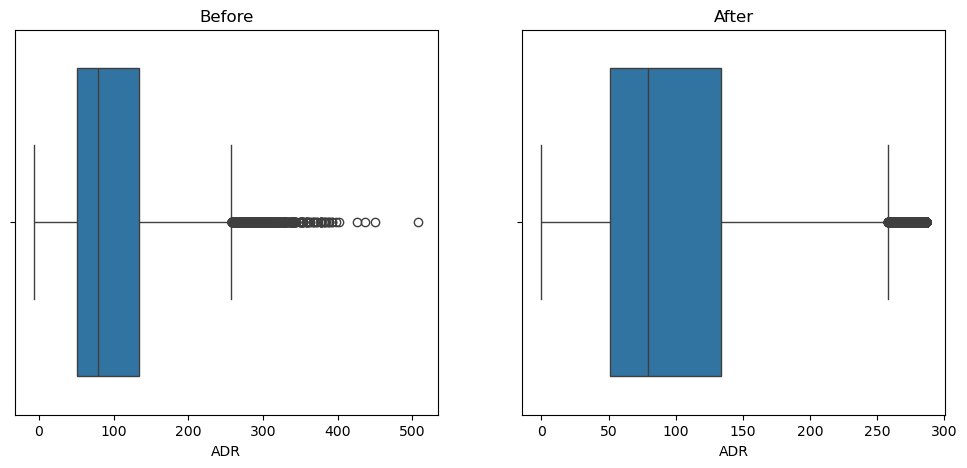

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['ADR'])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(x=df_cleaned['ADR'])
plt.title("After")

plt.show()

In [32]:
df_cleaned.to_csv(r"Data\H1_cleaned_feature_engineering.csv")